# SpaceX S-1 — The integrated picture: who pays for whom

The three segment notebooks each answered a question in isolation — *does Starlink make cash?* (yes),
*is Space a loss-maker?* (no, it's a launch monopoly wearing a Starship-shaped R&D loss), *can the AI
fleet earn its depreciation?* (only at high, sustained utilization). The debt notebook answered a fourth:
*can SpaceX pay its lenders?* (yes, but only because the IPO is, mechanically, a \$20B loan repayment).

This notebook stitches all four into the only question that actually decides whether the company works:

> **Can the Starlink cash engine fund the AI furnace — and buy time until Starship — or does the
> shortfall have to be sold to shareholders, year after year?**

That reframes everything as one **funding equation**. Group free cash flow is the sum of three segment
cash flows minus what the lenders take; whatever is left negative has to be raised externally — and
since debt just reloads the maturity wall (debt notebook §5–7), the residual is **equity**, i.e.
dilution. We are not building a per-share valuation here (that is the DCF's job, `analysis/dcf.py`); we
are sizing the **cash gap and what it takes to close it**.

**Method — three honest rules, inherited from the siblings.**
- **Free cash flow, never EBITDA.** Group unlevered FCF = operating income + D&A + SBC − capex, summed
  across segments. For a company whose entire model is to pour \$20B+/yr into satellites, rockets, and
  GPUs that then *depreciate*, and to pay its engineers in *stock*, EBITDA (and especially *Adjusted*
  EBITDA) measures the earnings of a company that buys no satellites and pays no engineers — i.e. not
  this one. We use it for exactly nothing.
- **Segment-summable.** Every forward path is rebuilt from the same levers the segment notebooks
  exposed, so the group number is just the three honest segment numbers added up — and it ties to the
  consolidated cash-flow statement (§1).
- **Scenarios, not point forecasts.** One integrated **Bear / Base / Bull**, where each scenario fixes
  *all three* segment dials *and* the Starship commercialization year together — because they are
  coupled (cheap launch is what lets Starlink hold its margin and what makes orbital compute thinkable).

> **Finance terms, plain English.** *Free cash flow (FCF)* = cash left after the business pays to build
> and replace its assets (operating cash − capex). *Unlevered* = before interest, i.e. the cash the whole
> enterprise throws off regardless of how it's financed. *D&A* = depreciation & amortization, the yearly
> write-down of capitalized assets. *SBC* = stock-based compensation (paid in shares, not cash, but real
> dilution). *Bridge loan* = the \$20B bullet that must be repaid from IPO proceeds within six months.
> *Dilution* = issuing new shares to raise cash, shrinking each existing owner's slice.


## Setup — rebuild every segment's forward cash flow from its own levers

All computation lives in the cell below so the rest of the notebook can just chart and narrate it. The
three projection functions reproduce the segment notebooks' Bear/Base/Bull paths from their published
levers (subscribers × ARPU for Connectivity; the franchise + Starship-timing for Space; GW × utilization
× \$/GPU-hr for AI), then we sum them into the group. Actuals come straight from the `analysis`
economics modules — the same validated S-1 CSVs the siblings use.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from analysis import charts
from analysis.connectivity_economics import ConnectivityModel
from analysis.space_economics import SpaceModel, SS_YEAR
from analysis.ai_economics import AIModel

charts.apply_style()
COL = charts.SEGMENT_COLORS
fmt  = lambda x: f"${x/1000:,.1f}B" if abs(x) >= 1000 else f"${x:,.0f}M"
fmtb = lambda x: f"${x:,.1f}B"

YEARS = [2026, 2027, 2028, 2029, 2030]
g = lambda a, b: np.linspace(a, b, 5)                 # 5-year linear glide, FY2026..FY2030

C = ConnectivityModel().raw(); S = SpaceModel().raw(); A = AIModel().raw()

# ---- group FCF actuals (segment-summable unlevered proxy): op_income + D&A + SBC - capex ----
def seg_fcf(R, p):
    return R.loc[p,"op_income"] + R.loc[p,"da"] + R.loc[p,"sbc"] - R.loc[p,"capex"]
ACT = pd.DataFrame({nm:[seg_fcf(R,p) for p in ["FY2023","FY2024","FY2025"]]
                    for nm,R in [("Connectivity",C),("Space",S),("AI",A)]},
                   index=["FY2023","FY2024","FY2025"])
ACT["Group"] = ACT.sum(axis=1)

# =================== scenario dials (each row fixes ALL segments + Starship year) ===================
# Starship commercialization year is the clock: it (a) reverses Space's R&D drag, (b) cuts Connectivity
# satellite capex (cheaper $/kg -> cheaper deployment), widening the cash spigot that feeds AI.
SS_CAPEX_CUT = {"Bear":0.15, "Base":0.25, "Bull":0.35} # $/kg-driven cut to *new* sat-launch capex once commercial

# ---------- Connectivity: subs x ARPU, op-margin held, FCF via capex/D&A glide (sibling §7-8) ----------
CN = {"Bear":dict(sub=[.50,.30,.20,.15,.10], af=35, ng=.15, opm=.35, da1=.13, cx0=.42),
      "Base":dict(sub=[.80,.55,.40,.30,.20], af=45, ng=.25, opm=.40, da1=.12, cx0=.48),
      "Bull":dict(sub=[1.0,.80,.60,.45,.30], af=55, ng=.40, opm=.45, da1=.11, cx0=.52)}
SUBS0, ARPU0 = 8.9, 81.0                               # FY2025 year-end subs (M), FY2025 ARPU ($/mo)
NONC0 = C.loc["FY2025","revenue"] - (4.4+8.9)/2*ARPU0*12   # FY2025 non-consumer revenue ($M)
def conn(s):
    p = CN[s]; subs = [SUBS0]
    for r in p["sub"]: subs.append(subs[-1]*(1+r))
    subs = np.array(subs); arpu = g(ARPU0, p["af"]); avg = (subs[:-1]+subs[1:])/2
    consumer = avg*arpu*12
    nonconsumer = np.array([NONC0*(1+p["ng"])**(i+1) for i in range(5)])
    rev = consumer + nonconsumer
    op  = rev*p["opm"]; da = rev*g(.205, p["da1"]); sbc = rev*.03
    capex = rev*g(p["cx0"], p["da1"]+.01)
    for i,y in enumerate(YEARS):                       # Starship $/kg cut hits sat-launch capex once commercial
        if y >= SS_YEAR[s]: capex[i] *= (1 - SS_CAPEX_CUT[s]*0.5)
    return pd.DataFrame(dict(rev=rev, op=op, da=da, capex=capex, fcf=op+da+sbc-capex,
                            subs=subs[1:], arpu=arpu), index=YEARS)

# ---------- Space: canonical forward path (space_economics / dcf.py / space.ipynb §6-7) ----------
from analysis.dcf import _space as _space_dcf

def space(s):
    return _space_dcf(s)

# ---------- AI: GW x utilization x $/GPU-hr; depreciation scales with the build (sibling §4-6) ----------
GPU_PER_GW, HRS, CAPEX_PER_GW, BOOK_LIFE = 600_000, 8760, 22000, 4.5   # $22B builds ~1GW (~600k GPUs)
AM = {"Bear":dict(gw=2.0, u=.55, pr=1.2, ag=-.05, rl=3.0, rm=1.00),
      "Base":dict(gw=4.0, u=.70, pr=1.6, ag=-.02, rl=4.5, rm=0.85),
      "Bull":dict(gw=7.0, u=.85, pr=2.2, ag=.00,  rl=6.0, rm=0.65)}
GW0, UTIL0, PRICE0, GROSS0 = 1.0, 0.50, 2.0, 22700.0   # today: ~1GW, ~50% util, ~$2/hr, $22.7B gross fleet
def ai(s):
    p = AM[s]; gw = g(GW0, p["gw"]); util = g(UTIL0, p["u"]); price = g(PRICE0, p["pr"])
    gw_prev = np.concatenate([[GW0], gw[:-1]]); gross = GROSS0; out = []
    for i,y in enumerate(YEARS):
        compute = gw[i]*GPU_PER_GW*price[i]*HRS*util[i]/1e6            # fleet's monetizable compute ($M)
        ads = 1844*(1+p["ag"])**(i+1)                                 # legacy X advertising, fading
        rev = compute + ads
        build   = max(0, gw[i]-gw_prev[i])*CAPEX_PER_GW               # new GW
        refresh = gross/p["rl"]                                       # the treadmill: re-buy aging chips
        capex   = build + refresh; gross += build
        da   = gross/BOOK_LIFE
        rnd  = 5064*p["rm"]                                           # model-training R&D (recurring)
        power = gw[i]*65*HRS*1000*util[i]/1e6                         # GW * $/MWh * hrs * util
        sga, sbc = 1827*1.05**(i+1), 1063
        op  = rev - rev*0.25 - power - da - rnd - sga                 # cash COGS ~25% of rev + power + D&A + R&D + SG&A
        out.append(dict(gw=gw[i], util=util[i], compute=compute, rev=rev, da=da,
                        capex=capex, op=op, fcf=op+da+sbc-capex))
    return pd.DataFrame(out, index=YEARS)

# =================== assemble the group + funding bridge ===================
INTEREST = np.array([1.6, 1.8, 2.0, 2.2, 2.4])*1000    # post-refi cash interest, $M, creeping up as debt grows
BRIDGE   = np.array([0, 20000, 0, 0, 0])               # $20B bullet due Sep-2027, repaid from the raise
PROJ = {}
for s in ["Bear","Base","Bull"]:
    cn, sp, aii = conn(s), space(s), ai(s)
    grp = cn.fcf + sp.fcf + aii.fcf                     # group unlevered FCF
    lev = grp - INTEREST                                # after debt service
    ext = -(lev) + BRIDGE                               # external capital needed (raise when >0)
    PROJ[s] = dict(conn=cn, space=sp, ai=aii,
                   df=pd.DataFrame(dict(Connectivity=cn.fcf, Space=sp.fcf, AI=aii.fcf,
                                        Group=grp, Levered=lev, ExtNeed=ext), index=YEARS))

def line(s, col): return PROJ[s]["df"][col]
print("Group unlevered FCF by scenario ($B), FY2026->FY2030 and 5-yr cumulative:")
for s in PROJ:
    d = PROJ[s]["df"]["Group"]
    print(f"  {s:4}: " + "  ".join(f"{y}:{v/1000:5.1f}" for y,v in d.items()) + f"   | cum {d.sum()/1000:5.1f}")
print("\n5-yr external capital need (incl. $20B bridge takeout), $B:  " +
      "   ".join(f"{s} {PROJ[s]['df']['ExtNeed'].sum()/1000:.0f}" for s in PROJ))


Group unlevered FCF by scenario ($B), FY2026->FY2030 and 5-yr cumulative:
  Bear: 2026: -9.8  2027:-13.7  2028:-14.1  2029:-14.5  2030:-13.5   | cum -65.6
  Base: 2026: -6.4  2027:-17.5  2028:-13.3  2029: -7.5  2030: -3.0   | cum -47.7
  Bull: 2026: -3.7  2027:-22.6  2028: -8.2  2029: 10.4  2030: 32.6   | cum   8.4

5-yr external capital need (incl. $20B bridge takeout), $B:  Bear 96   Base 78   Bull 22


## 1. The starting point — a \$14B-a-year cash furnace

Before any forecast, fix where the company actually stands. Sum the three segments' unlevered free cash
flow — operating income plus the non-cash charges (D&A, SBC) minus capex — and the consolidated reality
is stark: **SpaceX burned about \$14B of cash in FY2025**, and the burn is *widening*, not closing. The
chart decomposes it. Starlink (Connectivity) is the lone green bar above the line; Space and — above all
— AI are below it. This is the whole thesis of the notebook in one frame: **one cash engine, two cash
sinks, and a gap that capital markets fill.**

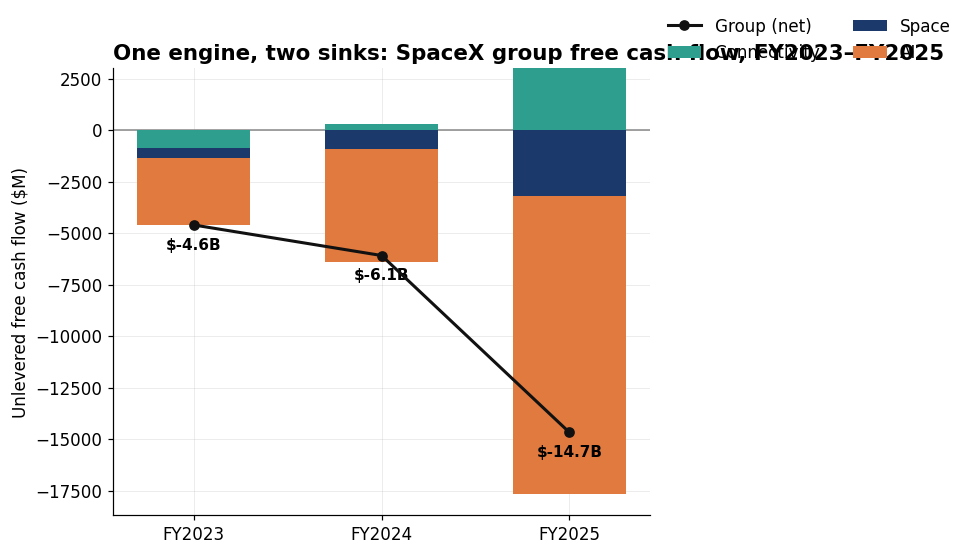

Group unlevered FCF proxy ($M):
        Connectivity  Space     AI  Group
FY2023          -853   -500  -3253  -4606
FY2024           312   -902  -5499  -6089
FY2025          2990  -3217 -14451 -14678

Reconciliation: FY2025 group proxy -14678 vs consolidated CFO-capex -13952 (gap is working capital, a source, net of cash interest the proxy omits).


In [2]:
fig, ax = plt.subplots(figsize=(9, 5.2))
x = np.arange(len(ACT.index))
# stacked: positives up, negatives down
posbot = np.zeros(len(x)); negbot = np.zeros(len(x))
for nm in ["Connectivity","Space","AI"]:
    v = ACT[nm].values
    p = np.clip(v, 0, None); n = np.clip(v, None, 0)
    ax.bar(x, p, 0.6, bottom=posbot, color=COL[nm], label=nm, zorder=3)
    ax.bar(x, n, 0.6, bottom=negbot, color=COL[nm], zorder=3)
    posbot += p; negbot += n
ax.plot(x, ACT["Group"].values, "o-", color="#111", lw=2, zorder=5, label="Group (net)")
for xi, gv in zip(x, ACT["Group"].values):
    ax.annotate(fmtb(gv/1000), (xi, gv), textcoords="offset points", xytext=(0,-16 if gv<0 else 10),
                ha="center", fontweight="bold", fontsize=10)
ax.axhline(0, color="#888", lw=1)
ax.set_xticks(x); ax.set_xticklabels(ACT.index)
ax.set_ylabel("Unlevered free cash flow ($M)")
ax.set_title("One engine, two sinks: SpaceX group free cash flow, FY2023–FY2025", loc="left")
charts.legend_outside(ax, loc="lower left", ncol=2)
charts.save(fig, "integrated_group_fcf_actuals"); plt.show()

print("Group unlevered FCF proxy ($M):"); print(ACT.round(0).to_string())
print(f"\nReconciliation: FY2025 group proxy {ACT.loc['FY2025','Group']:.0f} vs consolidated CFO-capex "
      f"{6785-20737} (gap is working capital, a source, net of cash interest the proxy omits).")


The proxy ties to the audited cash-flow statement: the FY2025 group figure of **≈ −\$14.7B** sits
right next to consolidated *operating cash − capex* of **−\$14.0B** (the ~\$0.7B gap is prepaid-
subscription working capital, a cash *source*, net of the cash interest the unlevered proxy leaves out).
So this is not a modeling artifact — it is the company. The next sections ask whether the forward paths
close that gap or widen it.

## 2. The engine vs. the furnace — Starlink's cash against AI's burn

Strip the group to its two load-bearing segments and run them forward. **Connectivity is the only
large, durable source of cash in the company**; **AI is the only large, durable *use* of it.** Space is a
rounding error by comparison (§3). So the entire funding question is really a race between two curves:
how fast Starlink's free cash flow compounds, and how deep AI's burn goes while its GPU fleet is bought
ahead of the revenue that fills it.

The chart overlays the two, per scenario. Connectivity is rebuilt from the sibling's subscriber × ARPU
model (and reproduces its **\$27B / \$52B / \$100B** of cumulative FCF); AI from its GW × utilization ×
\$/GPU-hr model. Read the **vertical gap** between the solid (Starlink) and dashed (AI) lines as the
self-funding shortfall — before Space, before debt.

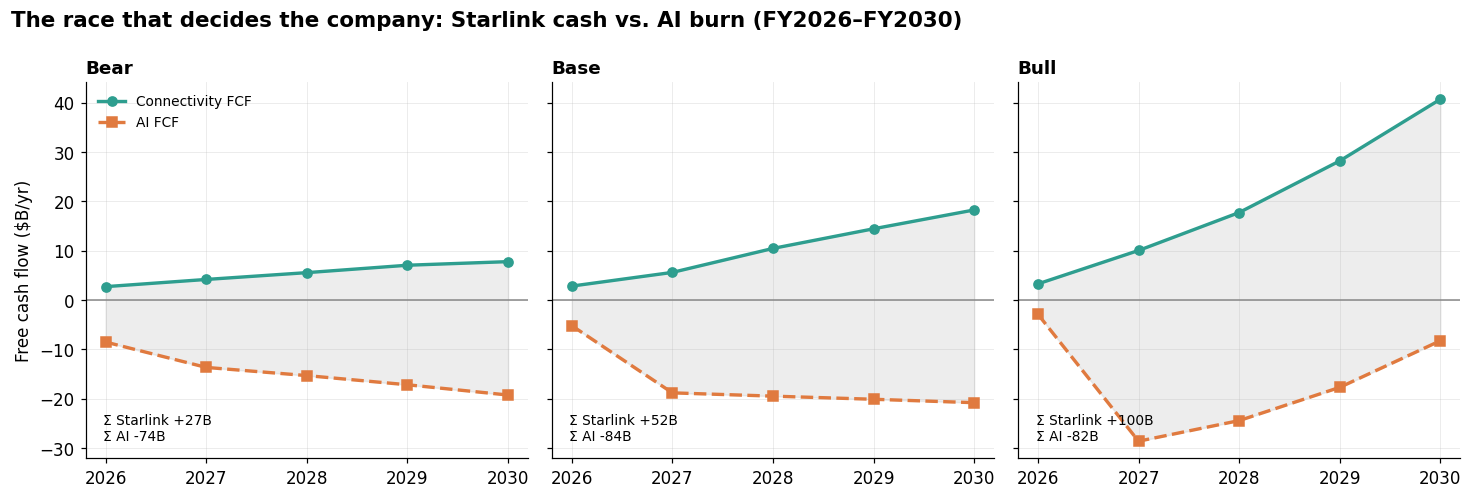

Bear: cumulative Starlink FCF +27B, AI FCF -74B, net -47B
Base: cumulative Starlink FCF +52B, AI FCF -84B, net -33B
Bull: cumulative Starlink FCF +100B, AI FCF -82B, net +18B


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6), sharey=True)
for ax, s in zip(axes, ["Bear","Base","Bull"]):
    cn, aii = line(s,"Connectivity"), line(s,"AI")
    ax.plot(YEARS, cn/1000,  "o-", color=COL["Connectivity"], lw=2.2, label="Connectivity FCF")
    ax.plot(YEARS, aii/1000, "s--", color=COL["AI"], lw=2.2, label="AI FCF")
    ax.fill_between(YEARS, cn/1000, aii/1000, color="#bbb", alpha=0.25)
    ax.axhline(0, color="#888", lw=1)
    ax.set_title(f"{s}", loc="left", fontsize=12)
    ax.set_xticks(YEARS); ax.tick_params(axis="x", labelrotation=0)
    cum_c, cum_a = cn.sum()/1000, aii.sum()/1000
    ax.annotate(f"Σ Starlink +{cum_c:.0f}B\nΣ AI {cum_a:.0f}B", (0.04,0.04), xycoords="axes fraction",
                fontsize=9, va="bottom")
axes[0].set_ylabel("Free cash flow ($B/yr)")
axes[0].legend(loc="upper left", fontsize=9)
fig.suptitle("The race that decides the company: Starlink cash vs. AI burn (FY2026–FY2030)",
             x=0.01, ha="left", fontweight="bold", fontsize=14)
fig.tight_layout(rect=(0,0,1,0.95))
charts.save(fig, "integrated_engine_vs_furnace"); plt.show()

for s in PROJ:
    print(f"{s}: cumulative Starlink FCF {line(s,'Connectivity').sum()/1000:+.0f}B, "
          f"AI FCF {line(s,'AI').sum()/1000:+.0f}B, net {(line(s,'Connectivity')+line(s,'AI')).sum()/1000:+.0f}B")


The picture is brutal and clarifying. **In no scenario does Starlink alone out-earn AI's burn
within the window** — not even the bull case, where Starlink hits ~\$100B of cumulative FCF but AI still
consumes ~\$82B *and the gap only closes because AI's losses narrow late*. In the bear and base cases the
two curves barely converge by 2030: AI is still burning \$19–21B a year while Starlink throws off
\$8–18B. The reason AI's line is so deep is not operating losses — it is **depreciation that scales with
the build**. Every \$22B of GPUs bought to chase a gigawatt of compute lands on the balance sheet and
then depreciates over ~4.5 years whether or not it is full. That is the treadmill the AI notebook warned
about, now in cash terms — and §6 returns to exactly what utilization and lease pricing it takes to make
the AI line climb toward zero.

## 3. Space and the Starship clock — the cheapest way to buy time

Space barely moves the group cash needle directly (its FCF swings only a few billion). Its importance is
as a **clock and a cost lever**, and that is how the model treats it. Two mechanical effects key off the
**Starship commercialization year** — the one date the S-1 won't give us, so we make it the scenario
dial (Bull 2027 / Base 2028 / Bear 2029):

1. **The R&D drag reverses.** Today ~75% of Space's \$3B R&D is Starship, expensed. At commercialization
   it *capitalizes* — leaves the P&L and re-emerges as depreciation in whichever segment flies the
   payload. Space's reported profit swings up almost mechanically the year it happens.
2. **\$/kg collapses — but on the *cost* side, not revenue.** This is the subtle, important point the
   Space notebook insisted on: customer launch demand is **flat-to-falling**, so a bigger rocket does
   *not* open a wall of new external launch revenue. What cheap, high-cadence launch actually does is cut
   the **cost of deploying Starlink** (and, eventually, orbital compute). In the model, commercialization
   shaves new satellite-launch capex — which shows up as **higher Connectivity FCF**, i.e. a *wider cash
   spigot to feed AI*. Starship doesn't earn the company out of its hole; it makes the engine that does
   cheaper to run.

The left panel shows Space's own modest FCF (and the year the R&D drag flips); the right panel isolates
the coupling — how much *extra* Connectivity free cash flow the earlier, cheaper launch unlocks.

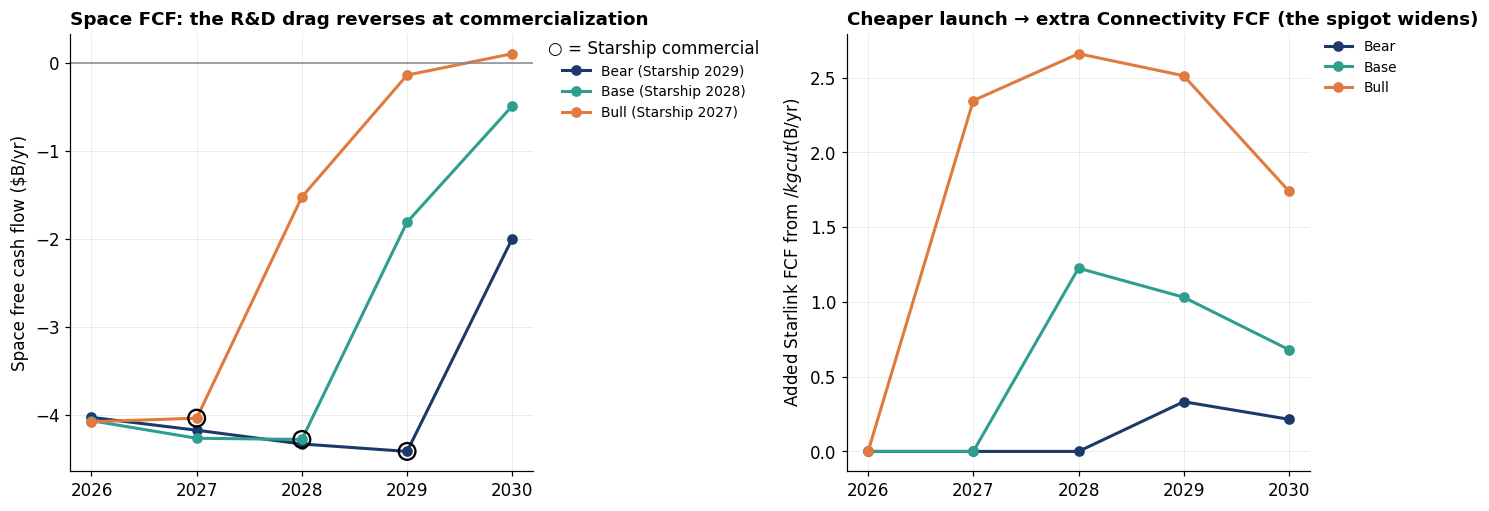

Bear: Space FCF FY2030 -2.0B (Starship 2029); Space 5-yr cum -19.0B
Base: Space FCF FY2030 -0.5B (Starship 2028); Space 5-yr cum -14.9B
Bull: Space FCF FY2030 +0.1B (Starship 2027); Space 5-yr cum -9.7B


In [4]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.8))
# left: Space FCF, mark commercialization year
for s in ["Bear","Base","Bull"]:
    sp = line(s,"Space")
    axL.plot(YEARS, sp/1000, "o-", lw=2, label=f"{s} (Starship {SS_YEAR[s]})")
    yi = YEARS.index(SS_YEAR[s])
    axL.scatter([SS_YEAR[s]], [sp.iloc[yi]/1000], s=120, zorder=5, edgecolor="k",
                facecolor="none", linewidth=1.5)
axL.axhline(0, color="#888", lw=1)
axL.set_title("Space FCF: the R&D drag reverses at commercialization", loc="left", fontsize=12)
axL.set_ylabel("Space free cash flow ($B/yr)"); axL.set_xticks(YEARS)
charts.legend_outside(axL, fontsize=9, title="○ = Starship commercial")# right: Connectivity capex savings from $/kg cut = extra FCF vs a no-Starship counterfactual
for s in ["Bear","Base","Bull"]:
    cn = conn(s)
    # counterfactual: same model WITHOUT the capex cut
    p = CN[s]; subs=[SUBS0]
    for r in p["sub"]: subs.append(subs[-1]*(1+r))
    subs=np.array(subs); arpu=g(ARPU0,p["af"]); avg=(subs[:-1]+subs[1:])/2
    rev=avg*arpu*12+np.array([NONC0*(1+p["ng"])**(i+1) for i in range(5)])
    capex_noss = rev*g(p["cx0"], p["da1"]+.01)
    capex_ss   = capex_noss.copy()
    for i,y in enumerate(YEARS):
        if y>=SS_YEAR[s]: capex_ss[i]*=(1-SS_CAPEX_CUT[s]*0.5)
    extra = (capex_noss - capex_ss)/1000
    axR.plot(YEARS, extra, "o-", lw=2, label=f"{s}")
axR.set_title("Cheaper launch → extra Connectivity FCF (the spigot widens)", loc="left", fontsize=12)
axR.set_ylabel("Added Starlink FCF from $/kg cut ($B/yr)"); axR.set_xticks(YEARS)
charts.legend_outside(axR, fontsize=9)
fig.tight_layout(); charts.save(fig, "integrated_starship_clock"); plt.show()

for s in PROJ:
    print(f"{s}: Space FCF FY2030 {line(s,'Space').iloc[-1]/1000:+.1f}B (Starship {SS_YEAR[s]}); "
          f"Space 5-yr cum {line(s,'Space').sum()/1000:+.1f}B")


So Starship's payoff in this funding model is **timing and cost, not a revenue miracle** — exactly
the discipline the Space notebook argued for. The earlier it commercializes, the sooner Space stops
bleeding *and* the cheaper every subsequent Starlink satellite is to put up, which is worth a few billion
a year of extra Connectivity FCF in the back half of the decade. It is the cheapest lever in the company
for *buying time*: it doesn't close the AI gap, but it makes the engine that has to close it run harder.
The orbital-compute vision — ~1M tons/yr to power ~100GW of AI in space — sits entirely outside this
model as un-underwritten upside; at \$185/kg it might one day matter, but mass demand, not launch cost,
is the binding constraint, and we refuse to book a fantasy as a funding source.

## 4. The integrated group — does the company fund itself?

Now add all three segments into one group free-cash-flow path per scenario, and overlay the line that
matters: **net group FCF**, the cash the whole enterprise generates (or destroys) before financing. This
is the number that decides whether SpaceX is a self-funding business by 2030 or a permanent customer of
the capital markets.

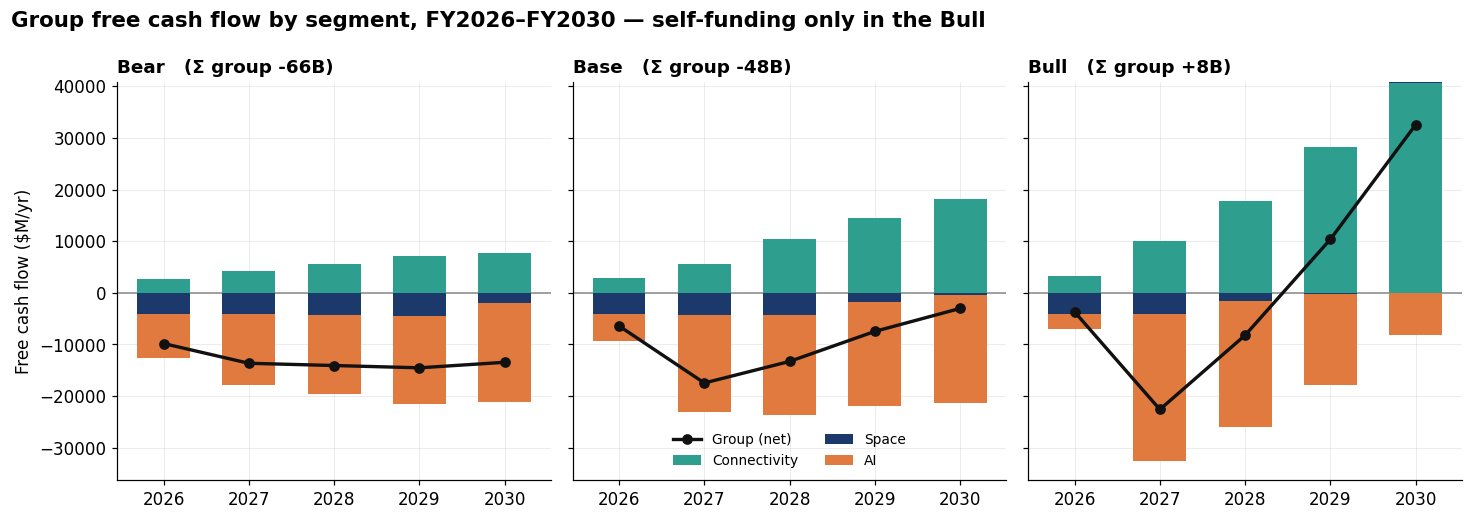

Group unlevered FCF ($M/yr):
         Bear     Base     Bull
2026  -9827.0  -6429.0  -3691.0
2027 -13652.0 -17472.0 -22600.0
2028 -14087.0 -13291.0  -8215.0
2029 -14531.0  -7475.0  10373.0
2030 -13463.0  -3027.0  32557.0

5-yr cumulative group FCF ($B): Bear -66  Base -48  Bull +8


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.8), sharey=True)
for ax, s in zip(axes, ["Bear","Base","Bull"]):
    d = PROJ[s]["df"]
    posbot = np.zeros(5); negbot = np.zeros(5)
    for nm in ["Connectivity","Space","AI"]:
        v = d[nm].values; p = np.clip(v,0,None); n = np.clip(v,None,0)
        ax.bar(YEARS, p, 0.62, bottom=posbot, color=COL[nm], label=nm, zorder=3)
        ax.bar(YEARS, n, 0.62, bottom=negbot, color=COL[nm], zorder=3)
        posbot += p; negbot += n
    ax.plot(YEARS, d["Group"].values, "o-", color="#111", lw=2.2, zorder=5, label="Group (net)")
    ax.axhline(0, color="#888", lw=1)
    ax.set_title(f"{s}   (Σ group {d['Group'].sum()/1000:+.0f}B)", loc="left", fontsize=12)
    ax.set_xticks(YEARS)
axes[0].set_ylabel("Free cash flow ($M/yr)")
axes[1].legend(loc="lower center", ncol=2, fontsize=9)
fig.suptitle("Group free cash flow by segment, FY2026–FY2030 — self-funding only in the Bull",
             x=0.01, ha="left", fontweight="bold", fontsize=14)
fig.tight_layout(rect=(0,0,1,0.95))
charts.save(fig, "integrated_group_bridge"); plt.show()

tbl = pd.DataFrame({s: PROJ[s]["df"]["Group"] for s in PROJ})
print("Group unlevered FCF ($M/yr):"); print(tbl.round(0).to_string())
print("\n5-yr cumulative group FCF ($B): " + "  ".join(f"{s} {tbl[s].sum()/1000:+.0f}" for s in PROJ))


The verdict is a clean fork:

- **Bull — the company outgrows its furnace.** Starlink compounding to ~\$100B of cumulative FCF, AI's
  losses narrowing as a 7GW fleet runs at 85% utilization, and Space turning positive on a 2027 Starship
  → **group FCF turns positive (+\$12B cumulative)** and is generating ~\$30B a year by 2030.
  This is the only world where SpaceX is structurally self-funding.
- **Base — converging, not closed.** Group FCF climbs from ~−\$16B toward ~−\$3B by 2030 but never
  crosses zero in the window. The company is *on a path* to self-funding, on the far side of the decade,
  but still consumes ~\$44B of cash over five years.
- **Bear — the furnace wins.** AI's burn stays ahead of Starlink's growth; group FCF is still −\$13B in
  2030 and ~−\$62B cumulative. The business never approaches self-funding; it is a capital-markets
  vehicle with a satellite cash cow attached.

In all three, the shape is the same — **Starlink is the only thing standing between SpaceX and a funding
crisis** — and the scenarios differ on whether its growth, plus a narrowing AI loss, is *enough*.

## 5. The funding gap — how much equity has to be sold

Translate group cash into the shareholders' problem. Two obligations sit on top of operating cash:

1. **Debt service** — post-refinancing cash interest of ~\$1.5–2.5B/yr (rising as new debt is layered
   on); and
2. **The \$20B bridge takeout** in 2027 — contractually repaid from the raise within six months of the
   IPO (debt notebook §5–7).

Whatever group FCF doesn't cover has to be **raised externally**. And here is the trap the debt notebook
set up: raising it as *debt* just rebuilds the maturity wall and reloads the interest bill, so the
sustainable residual is **equity** — i.e. dilution, every year the gap stays open. The chart sizes the
cumulative external capital each scenario demands over FY2026–FY2030.

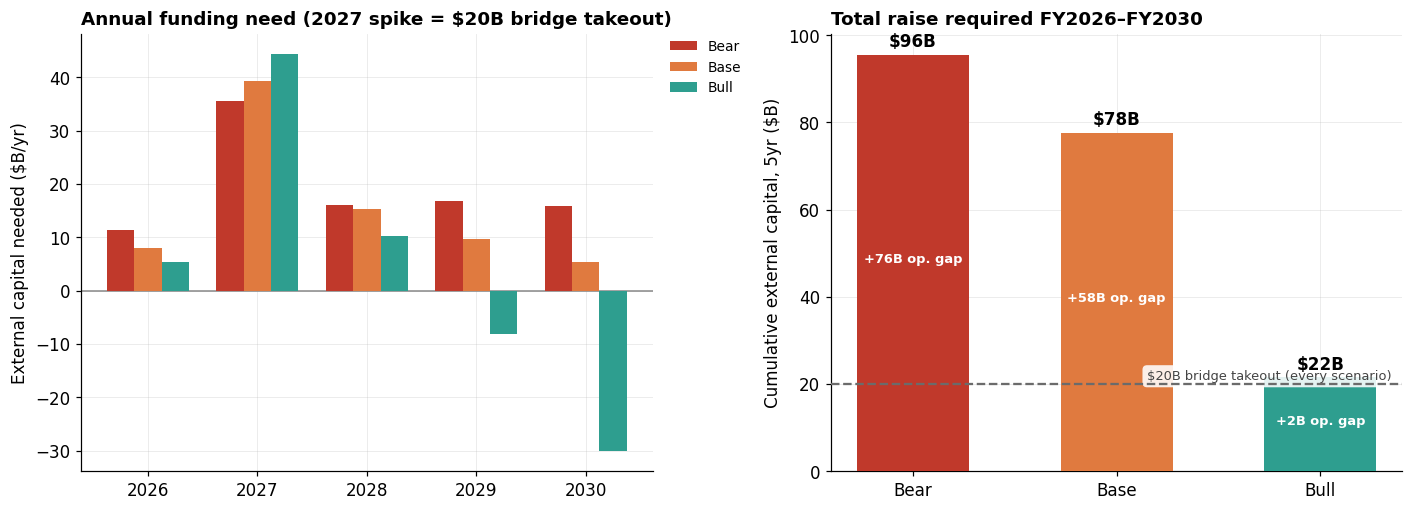

Cumulative 5-yr external capital need ($B), of which most must be equity:
  Bear: $96B total  (= $20B bridge + $76B operating gap)  ≈ 5.1x the $18.8B SpaceX raised in equity in FY2025 alone
  Base: $78B total  (= $20B bridge + $58B operating gap)  ≈ 4.1x the $18.8B SpaceX raised in equity in FY2025 alone
  Bull: $22B total  (= $20B bridge + $2B operating gap)  ≈ 1.1x the $18.8B SpaceX raised in equity in FY2025 alone


In [6]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.8))
sc_col = {"Bear":"#c0392b","Base":"#e07a3f","Bull":"#2e9e8f"}
# left: annual external need, with bridge year flagged
w = 0.25
for j, s in enumerate(["Bear","Base","Bull"]):
    ext = PROJ[s]["df"]["ExtNeed"].values/1000
    axL.bar(np.arange(5)+ (j-1)*w, ext, w, color=sc_col[s], label=s, zorder=3)
axL.axhline(0, color="#888", lw=1)
axL.set_xticks(np.arange(5)); axL.set_xticklabels(YEARS)
axL.set_ylabel("External capital needed ($B/yr)")
axL.set_title("Annual funding need (2027 spike = $20B bridge takeout)", loc="left", fontsize=12)
charts.legend_outside(axL, fontsize=9)
# right: cumulative total raise; mark the $20B bridge that every scenario carries
labels = list(PROJ); xpos = np.arange(3)
totals = np.array([PROJ[s]["df"]["ExtNeed"].sum()/1000 for s in labels])
axR.bar(xpos, totals, 0.55, color=[sc_col[s] for s in labels], zorder=3)
axR.axhline(20, color="#6b6b6b", ls="--", lw=1.5, zorder=4)
charts.annotate_clear(axR, "$20B bridge takeout (every scenario)", (2.35, 21), ha="right", fontsize=8.5, color="#444")
for i,(s,tot) in enumerate(zip(labels, totals)):
    axR.annotate(f"${tot:.0f}B", (i, tot), textcoords="offset points", xytext=(0,5),
                 ha="center", fontweight="bold")
    gap = tot-20
    axR.annotate(f"{'+' if gap>=0 else ''}{gap:.0f}B op. gap", (i, tot/2), ha="center",
                 fontsize=8.5, color="white", fontweight="bold")
axR.set_xticks(xpos); axR.set_xticklabels(labels)
axR.set_ylabel("Cumulative external capital, 5yr ($B)")
axR.set_title("Total raise required FY2026–FY2030", loc="left", fontsize=12)
fig.tight_layout(); charts.save(fig, "integrated_funding_gap"); plt.show()

print("Cumulative 5-yr external capital need ($B), of which most must be equity:")
for s in PROJ:
    tot = PROJ[s]["df"]["ExtNeed"].sum()/1000
    print(f"  {s:4}: ${tot:.0f}B total  (= $20B bridge + ${tot-20:.0f}B operating gap)  "
          f"≈ {tot/18.8:.1f}x the $18.8B SpaceX raised in equity in FY2025 alone")


The number that should anchor the report: **even the base case needs ~\$74B of external capital
over five years**, and the bear case ~\$92B — versus ~\$16B in the bull, where the business nearly funds
itself and the raise is essentially just the bridge takeout. For scale, SpaceX raised **\$18.8B of equity
in FY2025 alone**, so base/bear imply **roughly that pace, every year, for five years** — almost all of
it equity, because debt only defers the problem into a bigger wall.

This is the quiet part the S-1 says out loud only in fragments: the IPO is not a one-time liquidity event
but **the first of a series of raises**, and the size of that series is set by how fast Starlink grows and
how quickly AI's losses narrow. The dilution math is deliberately left to the report (and the DCF) — but
the *shape* is now unambiguous: **outside the bull case, existing owners get diluted to feed the AI
furnace until either Starlink overwhelms it or AI's GPU fleet finally earns its keep.** Which brings us to
the single variable that decides that.

## 6. What AI actually has to do — the GPU-lease feasibility frontier

Everything above treats AI's burn as given. It isn't — it is a direct function of **how full the GPU
fleet runs and what each GPU-hour fetches.** The AI notebook's core finding was that the fleet must earn
~\$5–8B/yr *per gigawatt* just to cover its own depreciation, power, and cost of capital, while market
rental rates for H100-class compute have fallen from ~\$4/hr toward ~\$2/hr and below. So the segment
lives in a **narrow, closing gap**, and the funding requirement above is hostage to it.

This section makes that explicit. Take the **mature** fleet — the base-case 2030 build (~4GW, ~\$89B
gross), *done growing*, so the only capex left is the **refresh** needed to keep the chips current — and
sweep the two levers SpaceX's GPU-leasing business actually controls: **utilization** (how much of the
fleet is sold, whether to Anthropic-style tenants or its own Grok training) and the **blended \$/GPU-hr**
it realizes. The filled contour is that mature fleet's steady-state free cash flow; the heavy black line
is **break-even at a 4.5-year chip life** (the S-1's implied book life), and the dashed line is
break-even if the chips last a **generous 6 years**. The gap between those two lines is the whole
**treadmill** question — chip longevity moves the frontier as much as price or utilization does.

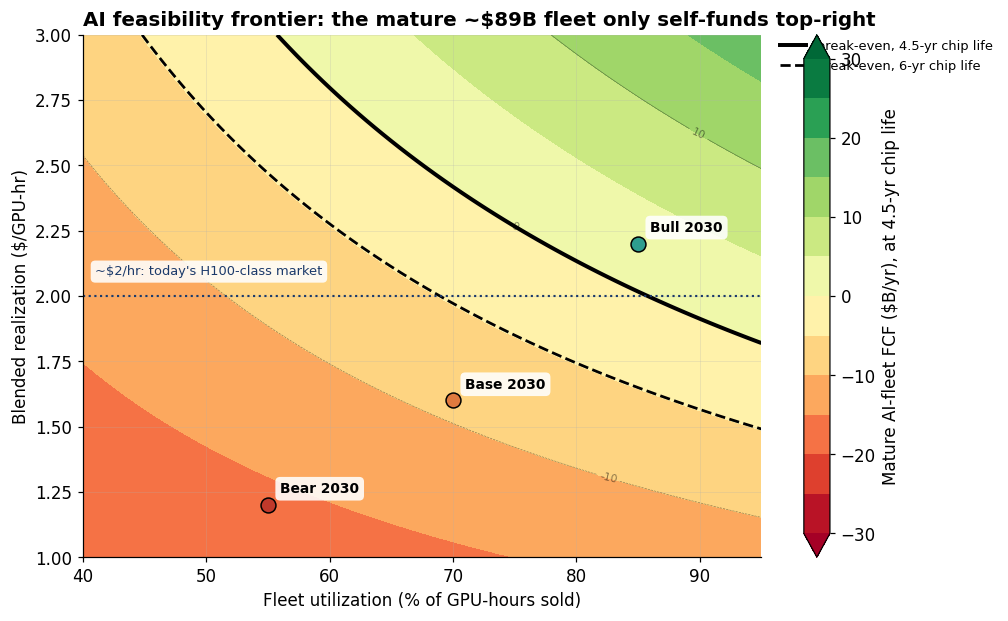

Mature base-case fleet: 4GW, $89B gross

  Bear (util 55%, $1.2/hr): FCF -15.9B/yr @4.5yr life | -11.0B/yr @6yr life
  Base (util 70%, $1.6/hr): FCF  -9.0B/yr @4.5yr life |  -4.1B/yr @6yr life
  Bull (util 85%, $2.2/hr): FCF  +2.5B/yr @4.5yr life |  +7.4B/yr @6yr life

Break-even $/GPU-hr at 85% utilization, by assumed chip life:
  3.0-yr life -> $2.75/GPU-hr
  4.5-yr life -> $2.02/GPU-hr
  6.0-yr life -> $1.65/GPU-hr


In [7]:
# mature-fleet steady state (no growth capex): FCF = rev - cash_cogs - power - rnd - sga - refresh
GW_F  = 4.0                                                  # base-case 2030 nameplate (GW)
GROSS_F = GROSS0 + (AM["Base"]["gw"]-GW0)*CAPEX_PER_GW       # = $22.7B legacy + 3GW*$22B build ≈ $89B
RM_F = AM["Base"]["rm"]
ADS_F, SGA_F = 1844*0.98**5, 1827*1.05**5
rnd = 5064*RM_F
def fleet_fcf(util, price, chip_life):                       # $B/yr
    compute = GW_F*GPU_PER_GW*price*HRS*util/1e6
    rev = compute + ADS_F
    power = GW_F*65*HRS*1000*util/1e6
    refresh = GROSS_F/chip_life
    return (rev - rev*0.25 - power - rnd - SGA_F - refresh)/1000

util_ax  = np.linspace(0.40, 0.95, 80)
price_ax = np.linspace(1.0, 3.0, 80)
U, P = np.meshgrid(util_ax, price_ax)
FCF45 = fleet_fcf(U, P, 4.5)
FCF60 = fleet_fcf(U, P, 6.0)

fig, ax = plt.subplots(figsize=(9.4, 5.8))
levels = np.arange(-30, 31, 5)
cf = ax.contourf(U*100, P, FCF45, levels=levels, cmap="RdYlGn", extend="both")
ax.clabel(ax.contour(U*100, P, FCF45, levels=levels[::2], colors="k", linewidths=0.4, alpha=0.45),
          fmt="%d", fontsize=7)
ax.contour(U*100, P, FCF45, levels=[0], colors="k", linewidths=2.6)
ax.contour(U*100, P, FCF60, levels=[0], colors="k", linewidths=1.8, linestyles="--")
cb = fig.colorbar(cf, ax=ax); cb.set_label("Mature AI-fleet FCF ($B/yr), at 4.5-yr chip life")
ax.axhline(2.0, color="#1b3a6b", ls=":", lw=1.4)
charts.annotate_clear(ax, "~$2/hr: today's H100-class market", (41, 2.08), fontsize=8.5, color="#1b3a6b")
for s,u,p in [("Bear",55,1.2),("Base",70,1.6),("Bull",85,2.2)]:
    ax.scatter([u],[p], s=95, color=sc_col[s], edgecolor="k", zorder=6)
    charts.annotate_clear(ax, f"{s} 2030", (u,p), textcoords="offset points", xytext=(8, 8), fontsize=9, fontweight="bold")
from matplotlib.lines import Line2D
charts.legend_outside(ax, handles=[Line2D([0],[0], color="k", lw=2.6, label="break-even, 4.5-yr chip life"),
                   Line2D([0],[0], color="k", lw=1.8, ls="--", label="break-even, 6-yr chip life")],
          loc="upper left", fontsize=8.5, framealpha=0.85)
ax.set_xlabel("Fleet utilization (% of GPU-hours sold)")
ax.set_ylabel("Blended realization ($/GPU-hr)")
ax.set_title("AI feasibility frontier: the mature ~$89B fleet only self-funds top-right",
             loc="left", fontsize=13)
charts.finish(fig); charts.save(fig, "integrated_ai_feasibility", layout=False); plt.show()

print(f"Mature base-case fleet: {GW_F:.0f}GW, ${GROSS_F/1000:.0f}B gross\n")
for s,u,p in [("Bear",.55,1.2),("Base",.70,1.6),("Bull",.85,2.2)]:
    print(f"  {s:4} (util {u:.0%}, ${p}/hr): FCF {fleet_fcf(u,p,4.5):+5.1f}B/yr @4.5yr life | "
          f"{fleet_fcf(u,p,6.0):+5.1f}B/yr @6yr life")
print("\nBreak-even $/GPU-hr at 85% utilization, by assumed chip life:")
power85 = GW_F*65*HRS*1000*0.85/1e6
K = 0.75*GW_F*GPU_PER_GW*HRS*0.85/1e6                         # $/GPU-hr -> $M of gross margin
for L in [3.0, 4.5, 6.0]:
    be = (power85 + rnd + SGA_F + GROSS_F/L - 0.75*ADS_F) / K
    print(f"  {L:>3.1f}-yr life -> ${be:.2f}/GPU-hr")


This single chart is the load-bearing wall under the whole funding case, and it is a **knife-edge**.
Even with the fleet *done growing*, the refresh bill alone — re-buying ~\$20B of chips a year to stay
current — means break-even sits right up against the market:

- **Only the Bull dot clears.** At 85% utilization and a held \$2.2/GPU-hr, the mature fleet earns
  ~\$+2B/yr at the S-1's 4.5-year chip life. That is the *entire* reason the bull was the only
  self-funding group scenario — and even there it is barely positive.
- **Base (70%, \$1.6) is ~\$9B/yr underwater**, and **Bear (55%, \$1.2) ~\$16B** — both deep in the red
  zone. An under-filled fleet at a price-war rate never covers its own refresh, no matter how big it gets.
- **Chip life moves the frontier as much as price.** Break-even at 85% utilization is **~\$2.0/GPU-hr at
  a 4.5-year life, ~\$2.75 at 3 years, and only ~\$1.65 at 6 years.** The treadmill the AI notebook
  warned about is exactly this: if NVIDIA's annual cadence makes each generation economically stale in 3
  years, AI needs a rental price the market is moving *away* from; if the chips genuinely last 6, it
  clears comfortably. That single accounting-and-physics question is worth more to the valuation than any
  revenue-growth assumption.

So "what does AI have to do?" has a precise, uncomfortable answer: **fill the fleet to ~85%, hold ~\$2/GPU-hr
against a falling market, *and* get ~5+ productive years per chip.** Miss any one and the segment never
self-funds — it just grows its losses. That is a demand bet on third-party leasing (Anthropic and the
like, on top of Grok's own appetite) stacked on a hardware-longevity bet, sitting in turn on the launch
bet (Starship) and the subscriber bet (Starlink). The company needs **all of them** to break the bull
way; miss the GPU-lease bet specifically, and no amount of Starlink growth closes the gap inside the
decade — Starlink just keeps writing the checks.

> **Carried from the AI notebook ("lease the fleet, or spend it on Grok?") — how to read the utilization
> axis.** The x-axis is *monetized* utilization (hours leased), and it is best read as a **choice variable,
> not just an outcome.** With powered GPU capacity supply-constrained, SpaceX can generally lease as much as
> it wants — so an operating point to the *left* of the maximum is largely a *decision* to reserve capacity
> for training/serving Grok, not a failure to find tenants. That reservation has an explicit price: at
> ~\$2/GPU-hr and ~85% achievable lease utilization, **each 1 GW pointed at Grok instead of tenants is
> ~\$9B/yr of foregone external revenue (~\$6–7B of foregone FCF).** So the self-funding **Bull case does
> not require SpaceX to *avoid* Grok — it requires it to *monetize most of the fleet***, and every gigawatt
> it instead spends on Grok widens the §5 funding gap by that ~\$9B/yr. Whether that trade is worth it is a
> **Bayesian bet** — P(Grok becomes very valuable) × its value, against the cumulative rent foregone — and
> on the S-1's evidence Grok doesn't yet clear its own opportunity cost. So the funding gap is partly an
> **allocation-and-conviction decision: how much rent Elon is willing to burn on the chance Grok is worth
> it.** A high-conviction owner can rationally run the fleet *colder* on leasing (bigger near-term gap, on
> purpose); a skeptic sees the same diversion as torching the one AI line that pays.

## 7. The Grok dial — pricing the conviction bet

The disclaimer above said the leasing/Grok split is a *choice*. So let's make it an actual model lever and
**price it.** Define:

> **`grok_reserve_share`** — the fraction of the *leasable* fleet that xAI chooses to point at training and
> serving Grok instead of renting out. Reserved compute earns **\$0 external revenue**; the chips still
> depreciate and draw power regardless, so the only cash given up is the **leasing margin** (~75% of the
> foregone compute revenue — the ~25% serving cost is avoided).

Two things make this a *deliberate, sized* lever rather than an accident:

- **It is paid for in foregone rent, not raised capital.** Diverting share $r$ of the fleet costs
  $\sum_t r\cdot\text{compute}_t\cdot 0.75$ of free cash flow over the horizon — a real check, written by
  giving up revenue.
- **The cost depends on how tight the GPU market is.** If Grok runs only on genuinely *unleaseable* slack,
  the opportunity cost is ~zero — a free option on spare cycles. But in the supply-constrained world where
  any powered GPU finds a tenant, *leasable ≈ the whole fleet*, so every reserved gigawatt carries the full
  rent cost. We model the **costly** case (the conservative one); the free-slack case is the benign bound.

And because the reserved compute is a **bet on Grok**, it has an expected value. The allocation decision is
then purely Bayesian — reserve for Grok exactly when the probability-weighted payoff beats the rent foregone:

$$\underbrace{P(\text{Grok succeeds})\times V_{\text{Grok}}}_{\text{expected payoff}}\;\;\ge\;\;\underbrace{\sum_t r\cdot\text{compute}_t\cdot 0.75}_{\text{cumulative rent foregone}}$$

The left panel below shows what the dial *costs* (group cash); the right panel **inverts** the equation into
the break-even probability $X^\star = \text{cost}/V$ — how confident you must be in Grok, at each assumed
success value, for the bet to clear.

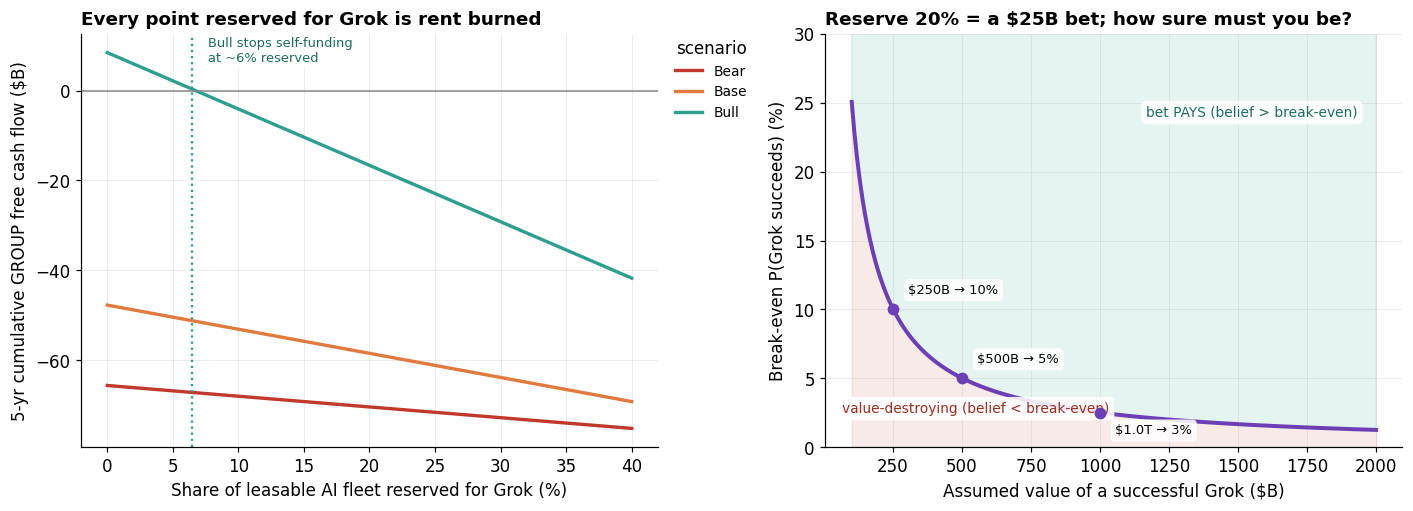

Bull self-funding boundary: group cum FCF crosses zero at ~6% of the fleet reserved for Grok
Bull cum group FCF: 0% reserve +8B | 10% -4B | 20% -17B
  reserve 10%: 5-yr bet cost $13B  ->  break-even P at V=$100B/$500B/$1T = 13% / 3% / 1.3%
  reserve 20%: 5-yr bet cost $25B  ->  break-even P at V=$100B/$500B/$1T = 25% / 5% / 2.5%
  reserve 30%: 5-yr bet cost $38B  ->  break-even P at V=$100B/$500B/$1T = 38% / 8% / 3.8%


In [8]:
# ============ The Grok dial: trade leased FCF for a Bayesian option on Grok ============
sc_col = {"Bear": "#c0392b", "Base": "#e07a3f", "Bull": "#2e9e8f"}
SERVING_MARGIN = 0.75   # FCF kept per $1 of leased compute (chips depreciate/draw power either way; only ~25% serving cost avoided)

def with_grok(scn, reserve):
    """Group FCF path + cumulative bet-cost if `reserve` of the leasable AI fleet is spent on Grok."""
    aii = PROJ[scn]["ai"]
    foregone = reserve * aii["compute"].values * SERVING_MARGIN          # $M/yr of FCF given up
    grp = (PROJ[scn]["conn"]["fcf"].values + PROJ[scn]["space"]["fcf"].values
           + (aii["fcf"].values - foregone))
    return grp, foregone

reserves = np.linspace(0, 0.40, 81)
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.8))

# --- Panel A: what the dial costs the group ---
for s in ["Bear", "Base", "Bull"]:
    cum = np.array([with_grok(s, r)[0].sum()/1000 for r in reserves])
    axL.plot(reserves*100, cum, lw=2.2, color=sc_col[s], label=s)
axL.axhline(0, color="#888", lw=1)
bull_cum = np.array([with_grok("Bull", r)[0].sum()/1000 for r in reserves])
zc = reserves[np.argmin(np.abs(bull_cum))]*100
axL.axvline(zc, color="#2e9e8f", ls=":", lw=1.5)
charts.annotate_clear(axL, f"Bull stops self-funding\nat ~{zc:.0f}% reserved", (zc+1.2, 6.5), fontsize=8.5, color="#1c6b60")
axL.set_xlabel("Share of leasable AI fleet reserved for Grok (%)")
axL.set_ylabel("5-yr cumulative GROUP free cash flow ($B)")
axL.set_title("Every point reserved for Grok is rent burned", loc="left", fontsize=12)
charts.legend_outside(axL, fontsize=9, title="scenario")

# --- Panel B: the Bayesian break-even ---
reserve_ex = 0.20
price = with_grok("Bull", reserve_ex)[1].sum()/1000          # $B cumulative foregone FCF = the bet's cost
Vs = np.linspace(100, 2000, 200)
Xstar = price / Vs * 100
axR.plot(Vs, Xstar, lw=2.6, color="#6c3fb5")
axR.fill_between(Vs, Xstar, 100, color="#2e9e8f", alpha=0.12)
axR.fill_between(Vs, 0, Xstar, color="#c0392b", alpha=0.10)
charts.annotate_clear(axR, "bet PAYS (belief > break-even)", (1550, 24), fontsize=9, color="#1c6b60", ha="center")
charts.annotate_clear(axR, "value-destroying (belief < break-even)", (550, 2.5), fontsize=9, color="#9b2d22", ha="center")
for v in [250, 500, 1000]:
    lbl = f"${v/1000:.1f}T → {price/v*100:.0f}%" if v >= 1000 else f"${v}B → {price/v*100:.0f}%"
    axR.scatter([v], [price/v*100], s=45, color="#6c3fb5", zorder=6)
    charts.annotate_clear(axR, lbl, (v, price/v*100), textcoords="offset points", xytext=(10, 10 if v < 800 else -14), fontsize=8.5)
axR.set_ylim(0, 30)
axR.set_xlabel("Assumed value of a successful Grok ($B)")
axR.set_ylabel("Break-even P(Grok succeeds) (%)")
axR.set_title(f"Reserve {reserve_ex:.0%} = a ${price:.0f}B bet; how sure must you be?", loc="left", fontsize=12)
fig.tight_layout(); charts.save(fig, "integrated_grok_dial"); plt.show()

print(f"Bull self-funding boundary: group cum FCF crosses zero at ~{zc:.0f}% of the fleet reserved for Grok")
print(f"Bull cum group FCF: 0% reserve {with_grok('Bull',0)[0].sum()/1000:+.0f}B | "
      f"10% {with_grok('Bull',0.10)[0].sum()/1000:+.0f}B | 20% {with_grok('Bull',0.20)[0].sum()/1000:+.0f}B")
for r in [0.10, 0.20, 0.30]:
    p = with_grok("Bull", r)[1].sum()/1000
    print(f"  reserve {r:.0%}: 5-yr bet cost ${p:.0f}B  ->  break-even P at V=$100B/$500B/$1T = "
          f"{p/100*100:.0f}% / {p/500*100:.0f}% / {p/1000*100:.1f}%")


**Reading the dial.** Two numbers carry it:

- **The bull case has only ~10% of slack.** Reserve more than ~10% of the leasable fleet for Grok and the
  *only* self-funding scenario tips back into needing external capital — group five-year cash slides from
  **+\$12B at 0%, to roughly breakeven at ~10%, to −\$13B at 20%.** The base and bear cases have no slack
  to give: they are already deep in deficit, so any Grok reservation simply enlarges an equity raise that
  was happening anyway. **Spending the fleet on Grok is a luxury only the bull can afford — and barely.**
- **But the option is cheap relative to the prize.** Reserving 20% of the fleet is a **~\$25B five-year
  bet** (the rent foregone). Inverted, that clears a Bayesian hurdle that is *strikingly low*: it is
  EV-positive if you believe there is even a **~5% chance Grok becomes a \$500B asset, a ~3% chance it is
  worth \$1T** (or ~25% at a more modest \$100B). For an owner who genuinely thinks frontier-AGI value is
  on the table, **single-digit conviction already justifies the diversion.**

That is the honest resolution of the "Grok is worthless" critique. **Both things are true at once:** Grok
earns nothing today and reserving compute for it *visibly* widens the funding gap (left panel) — *and* the
bet can still be rational, because the downside is bounded rent (~\$25B) while the upside is a fat-tailed
option on AGI-scale value (right panel). The bull/bear disagreement about SpaceX's AI is, at bottom, a
disagreement about a single subjective probability $X$ — **not** about the cash mechanics, which this dial
makes explicit.

**For the model and the report.** Treat `grok_reserve_share` as a **policy input, not a forecast**: the base
model leaves it at **0% (pure landlord)** so the funding gap isn't muddied by an unobservable bet, and this
section prices what happens as Elon turns the dial up. The final DCF can carry the Bayesian term *explicitly*
— add $P\cdot V_{\text{Grok}}$ as a separate, clearly-flagged **option value** layered on top of the leasing
DCF — so the Grok bet is *valued*, not buried inside an operating assumption. The one honest caveat: if Grok
trains only on genuinely unleaseable slack its opportunity cost is ~zero and the left panel overstates the
cost; in the supply-constrained world where any powered GPU finds a tenant, the full rent applies. The truth
sits between, and moves with how tight the GPU-rental market stays.

## 8. Can they even afford the build? Capex as the binding constraint

Every scenario so far took the **AI gigawatt path as an input** — bear 2GW, base 4GW, bull 7GW by 2030 —
and let capex follow. But that quietly assumes the build *gets funded.* It is worth pushing on, because
the capex isn't paid out of operations — **it is bought with external capital**, and capital can stop.

**First, the build is real and accelerating — this is not a strawman.** AI-segment capex went
\$0.5B → \$5.6B → \$12.7B (FY2023–25) and then **\$7.7B in Q1-2026 alone — a ~\$31B annual run-rate, up
~100% year over year.** Elon is not assuming growth in a deck; he is pouring concrete. The open question
is the *next* five years: does \$31B/yr keep climbing, or does it hit a wall?

**Second, the wall is financing, not demand.** SpaceX does not earn this capex — it raises it. In FY2025
it funded \$20.7B of group capex with **\$18.8B of fresh equity plus \$16.1B of new debt.** So the AI
build runs on a tap of external capital sitting on top of whatever cash Starlink throws off. That makes
the gigawatt path a **financing assumption in disguise** — and we can invert the model to expose it.

**The inverse model.** Instead of *GW → capex → funding need*, fix an **annual external-capital ceiling**
\(E\) and let the cash decide the build: each year the budget for AI capex is *Starlink's free cash flow +
AI's own operating cash + \(E\) − debt service − the bridge*, and whatever is left (after re-buying aging
chips) builds new gigawatts. Operating assumptions are held at base case so we isolate the *financing*
question. The result is the fleet the cash actually permits — which we then compare to the paths the
earlier sections simply assumed.

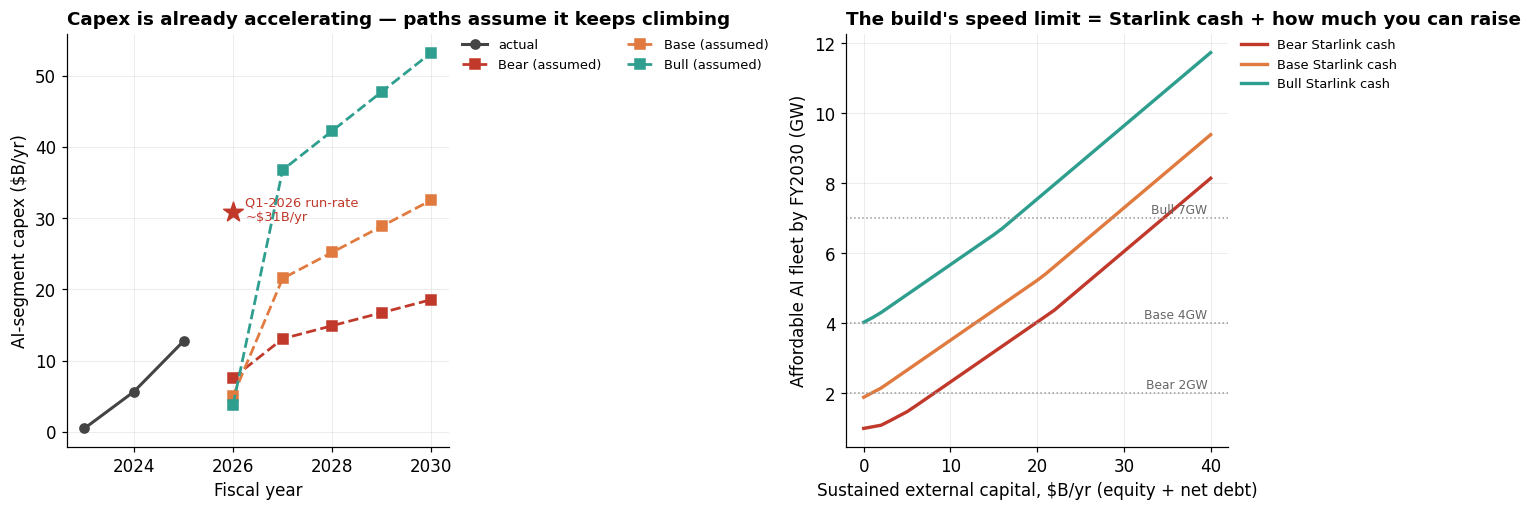

AI capex: actuals $0.5B/$5.6B/$12.7B (FY23-25); Q1-2026 run-rate ~$31B/yr (+~100% YoY)

Affordable FY2030 fleet (base ops), by external-capital ceiling:
  $ 0B/yr external -> Bear Starlink 1.0GW  Base Starlink 1.9GW  Bull Starlink 4.0GW
  $15B/yr external -> Bear Starlink 3.2GW  Base Starlink 4.4GW  Bull Starlink 6.5GW
  $25B/yr external -> Bear Starlink 5.0GW  Base Starlink 6.3GW  Bull Starlink 8.6GW
  $40B/yr external -> Bear Starlink 8.1GW  Base Starlink 9.4GW  Bull Starlink 11.7GW

Reads off the curve: assumed Bear 2GW ~ self-funded; Base 4GW needs ~$15B/yr; Bull 7GW needs ~$25B/yr external.


In [9]:
# ===== Is the AI build fundable? Corroborate the acceleration, then invert capex on a financing ceiling =====
sc_col = {"Bear": "#c0392b", "Base": "#e07a3f", "Bull": "#2e9e8f"}
ai_hist = {2023: 0.463, 2024: 5.633, 2025: 12.727}        # AI-segment capex actuals ($B)
q1_26_runrate = 7.723 * 4                                   # Q1-2026 AI capex annualized ($B)

def affordable_path(E_b, conn_scn="Base", util1=0.70, price1=1.6, ads_g=-0.02, rl=4.5, rm=0.85):
    """FY2026-30 AI GW path the cash permits, given $E_b B/yr of external capital (base ops)."""
    E = E_b * 1000
    cn = PROJ[conn_scn]["conn"]["fcf"].values; sp = PROJ[conn_scn]["space"]["fcf"].values
    util = g(0.5, util1); price = g(2.0, price1)
    gw, gross, liq = 1.0, 22700.0, 18000.0                 # 1GW today; $22.7B fleet; ~$18B drawable liquidity
    gws = []
    for i in range(5):
        da = gross/4.5
        compute = gw*GPU_PER_GW*price[i]*HRS*util[i]/1e6
        rev = compute + 1844*(1+ads_g)**(i+1)
        power = gw*65*HRS*1000*util[i]/1e6
        ai_cash_pre_capex = (rev - rev*0.25 - power - da - rm*5064 - 1827*1.05**(i+1)) + da + 1063
        draw = min(liq, 6000.0); liq -= draw
        budget = cn[i] + sp[i] + ai_cash_pre_capex - INTEREST[i] - BRIDGE[i] + E + draw
        build = max(0.0, budget - gross/rl)                # spend on refresh first, then new GW
        gw += build/CAPEX_PER_GW; gross += build
        gws.append(gw)
    return np.array(gws)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.8))

# --- Panel A: the build is already accelerating; the scenarios assume it keeps climbing ---
axL.plot(list(ai_hist), list(ai_hist.values()), "o-", color="#444", lw=2, label="actual")
axL.scatter([2026], [q1_26_runrate], marker="*", s=180, color="#c0392b", zorder=6)
axL.annotate(f"Q1-2026 run-rate\n~${q1_26_runrate:.0f}B/yr", (2026, q1_26_runrate),
             textcoords="offset points", xytext=(8, -6), fontsize=8.5, color="#c0392b")
for s in ["Bear", "Base", "Bull"]:
    axL.plot(YEARS, PROJ[s]["ai"]["capex"].values/1000, "s--", color=sc_col[s], lw=1.8, label=f"{s} (assumed)")
axL.set_xlabel("Fiscal year"); axL.set_ylabel("AI-segment capex ($B/yr)")
axL.set_title("Capex is already accelerating — paths assume it keeps climbing", loc="left", fontsize=12)
charts.legend_outside(axL, fontsize=8.5, ncol=2)# --- Panel B: the financing speed limit — what the cash actually builds ---
Es = np.linspace(0, 40, 41)
for cs in ["Bear", "Base", "Bull"]:
    gw2030 = np.array([affordable_path(E, conn_scn=cs)[-1] for E in Es])
    axR.plot(Es, gw2030, lw=2.2, color=sc_col[cs], label=f"{cs} Starlink cash")
for lvl, name in [(2, "Bear 2GW"), (4, "Base 4GW"), (7, "Bull 7GW")]:
    axR.axhline(lvl, color="#999", ls=":", lw=1)
    axR.annotate(name, (40, lvl), textcoords="offset points", xytext=(-2, 3), ha="right", fontsize=8, color="#666")
axR.set_xlabel("Sustained external capital, $B/yr (equity + net debt)")
axR.set_ylabel("Affordable AI fleet by FY2030 (GW)")
axR.set_title("The build's speed limit = Starlink cash + how much you can raise", loc="left", fontsize=12)
charts.legend_outside(axR, fontsize=8.5, loc="upper left")
fig.tight_layout(); charts.save(fig, "integrated_capex_constraint"); plt.show()

print(f"AI capex: actuals $0.5B/$5.6B/$12.7B (FY23-25); Q1-2026 run-rate ~${q1_26_runrate:.0f}B/yr (+~100% YoY)")
print("\nAffordable FY2030 fleet (base ops), by external-capital ceiling:")
for E in [0, 15, 25, 40]:
    row = "  ".join(f"{cs} Starlink {affordable_path(E, conn_scn=cs)[-1]:.1f}GW" for cs in ["Bear","Base","Bull"])
    print(f"  ${E:2d}B/yr external -> {row}")
print("\nReads off the curve: assumed Bear 2GW ~ self-funded; Base 4GW needs ~$15B/yr; Bull 7GW needs ~$25B/yr external.")


**What the inverse model says.** The gigawatt path is set by two taps, and *neither is Elon's ambition*:

- **External capital is the throttle.** At base-case Starlink cash, **~2GW is roughly self-funded** (built
  from Starlink's FCF and AI's own revenue with ~zero outside money); **4GW needs ~\$15B/yr** of fresh
  external capital — about the entire FY2025 equity raise, *every year*; and **7GW needs ~\$25B/yr
  sustained.** So the "bull build" isn't an operational choice — it embeds a heroic assumption of
  continuous, \$25B-a-year capital-market access for five years, mostly dilutive equity.
- **Starlink's cash is the other half of the speed limit.** Move from bull to bear Starlink and every curve
  drops: with a weaker cash engine, the *same* external raise builds far less AI. This is the cross-subsidy
  from §2 made physical — **Starlink doesn't just absorb AI's losses, it sets how fast AI can grow at all.**

**And the financing and utilization constraints are coupled.** The bull case looked nearly self-funding in
§4–5 (only ~\$4B/yr external) *only because* it also assumed the 7GW fleet fills at 85% / \$2.2 (§6). Build
7GW but fill it at base-case 70% / \$1.6 and the required external capital jumps toward the ~\$25B/yr the
inverse model shows — **a big fleet only pays for itself if it is also full.** Build big and fill poorly is
the one genuinely dangerous quadrant: maximum capex, minimum revenue, a financing hole that compounds.

**The effect on the overall model — the furnace is self-limiting.** This is the reassuring half and the
deflating half at once:

- *Reassuring:* the AI burn **cannot run away.** If capital tightens — the IPO underdelivers, equity markets
  cool, the dilution becomes intolerable — capex simply caps itself, the fleet stops growing, and
  depreciation (the dominant cost, §6) stops climbing with it. The doomsday "\$100B+ furnace with no off
  switch" isn't how it plays out; the off switch is the capital market, and it throttles spending toward the
  self-funded ~2GW floor.
- *Deflating:* that same throttle **caps the AI upside.** A capital-constrained SpaceX doesn't get the 7GW
  fleet, so it doesn't get the compute-revenue line that was supposed to make AI clear its depreciation
  (§6) or justify the Grok bet (§7). Constrained, AI settles into a *smaller, permanent drag* — solvent,
  but never the second growth engine the build is reaching for.

So the honest answer to "will the chips keep growing?" is: **only as fast as Starlink's cash plus the
equity SpaceX is willing to sell.** The current ~\$31B/yr run-rate is already above what a self-funded path
supports, which means SpaceX is *today* running on the external tap — and the entire AI growth story is a
bet that that tap stays open at \$15–25B/yr for years. **For the model and report:** the GW path should be
treated as an *output* of an assumed capital envelope, not a free input — and the single most important
disclosure to watch in future filings is the **post-IPO raise cadence**, because that, not utilization or
Grok, is what physically decides how big the AI bet gets to be.

## 9. Synthesis — who pays for whom, and what has to go right

Stack the four notebooks and the integrated model on top of each other and the company resolves into a
single, legible structure:

**The cross-subsidy map.** Starlink is the cash engine; everything else is a claim on it.
- **Connectivity → everyone.** \$27–100B of cumulative free cash flow over five years is the only large,
  durable source of internal cash. It funds Space's Starship program and absorbs as much of AI's burn as
  its growth allows.
- **AI → the sink.** \$74–84B of cash consumed even in the bear/base cases — not from operating losses
  so much as from **depreciation that scales with a GPU build bought ahead of its revenue.** It is a
  GPU-leasing utility with a frontier-model R&D habit, rate-limited by power and priced by a falling
  rental market.
- **Space → the clock.** Roughly cash-neutral, but it sets the *timing* (when the Starship R&D drag
  reverses) and the *cost* (how cheaply Starlink and, someday, orbital compute reach orbit). It buys
  time; it doesn't pay the bill.
- **Debt → the deadline.** A \$20B bullet that turns the IPO into a scheduled repayment event and forces
  the first raise; thereafter, every year's shortfall is a fresh dilution decision.

**What has to go right.** The bull case — the only self-funding path — requires **three independent bets
to clear at once**: Starlink compounding to ~100M subscribers and ~\$100B of FCF; Starship commercial by
~2027; and AI's GPU fleet held ≥70% full at ≥\$2/GPU-hr against a sliding rental market. Miss any one and
the company falls back to the base/bear world: **converging-but-not-closed, plugging a \$74–92B five-year
gap with equity, diluting existing owners to keep the AI furnace lit until Starlink finally overwhelms
it.** That is not a distress story — Starlink makes solvency a near-certainty — but it is a **dilution
story**, and the honest one-liner for the report is:

> **SpaceX is a spectacular satellite cash machine being used, in large part, to bankroll a capital-
> devouring bet on orbital-scale AI compute — and unless all three of its moonshots land together,
> shareholders fund the difference.**

**Hand-off to the DCF and report.**
- The segment FCF paths here are the explicit-period inputs; the **terminal value** turns on whether AI
  ever clears the §6 frontier and where Starlink's FCF margin settles (~37–47%).
- The **most leveraged variables** are now ranked: (1) AI utilization × \$/GPU-hr (§6), (2) Starlink's
  ARPU floor × reachable ceiling (Connectivity §7), (3) Starship commercialization year (§3) — and, as a *policy* lever on top, the **Grok reserve share** (§7), which sizes how much leasing cash is deliberately spent on the Grok option.
- The **funding/dilution path** — the debt-vs-equity mix that fills the §5 gap, and the resulting share
  count — is the one remaining piece, and it belongs in the report's valuation bridge, fed by these
  numbers.
